In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
#Load Auto MPG dataset

url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)

#Display first five rows

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
#Separate input and output

x = df[['displacement']]
y = df['mpg']

#check missing value

print("Missing values in ", x.isnull().sum())
print("Missing values in mpg:", y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values in mpg: 0


In [5]:
#remove rows containing missing values

data = df[['displacement', 'mpg']].dropna()

#update input&output

x = data[['displacement']]
y = data['mpg']

#display the selected data

print("Feature:")
print(x.head())

print("\nTarget:")
print(y.head())

Feature:
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


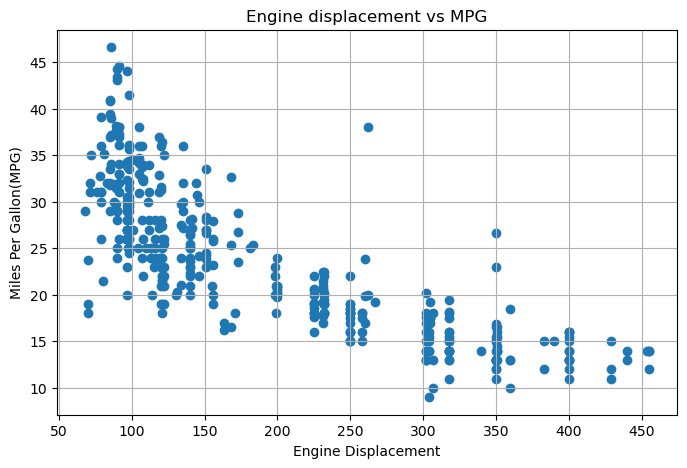

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(x,y)


plt.xlabel("Engine Displacement")
plt.ylabel("Miles Per Gallon(MPG)")
plt.title("Engine displacement vs MPG")

plt.grid(True)
plt.show()

In [7]:
#split dataset

x_train , x_test , y_train , y_test = train_test_split(
    x , y ,
    test_size = 0.2,
    random_state = 42
)

print("Training Samples:", len(x_train))
print("Training samples:", len(x_test))

Training Samples: 318
Training samples: 80


In [8]:
#create linear regression model
linear_model = LinearRegression()

#train model
linear_model.fit(x_train,y_train)

#predict on test data
y_pred_linear = linear_model.predict(x_test)


In [25]:
#calculate MSE
mse_linear = mean_squared_error(y_test,y_pred_linear)

#calculate R-squared
r2_linear = r2_score(y_test,y_pred_linear)

print("Linear Regression results")
print("-------------------------")
print("MSE:",mse_linear)
print("r-squared:",r2_linear)

Linear Regression results
-------------------------
MSE: 18.102543998358946
r-squared: 0.6633114869465595


In [36]:
#store result
results = []

#store polynomial model for plotting
polynomial_models = {}

#add linear regression result
results.append({
     'Model':'Linear Regression',
     'Degree': 1,
     'MSE':mse_linear,
     'R-squared':r2_linear
})

#try polynomial degrees 2 to 5
for degree in range(2,6):
    #create polynomial feature
    poly = PolynomialFeatures(degree=degree)
    
    #transform traing and testing data
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    #create linear regression model
    poly_model = LinearRegression()
    
    #train polynomial regression
    poly_model.fit(x_train_poly,y_train)
    
    #make predictions
    y_pred_poly = poly_model.predict(x_test_poly)
    
    #calculate evaluation metrices
    mse = mean_squared_error(y_test,y_pred_poly)
    r2 = r2_score(y_test,y_pred_poly)
    
    #store result
    results.append({
        'Model':'Linear Regression',
        'Degree':degree,
        'MSE':mse,
        'R-squared':r2
    })
    
    #store model and polynomial transformer
    polynomial_models[degree] = {
        'poly':poly,
        'model':poly_model
    }

#convert result into dataframe
results_df = pd.DataFrame(results)

#display result
results_df



,Model,Degree,MSE,R-squared
0,Linear Regression,1,18.102544,0.663311
1,Linear Regression,2,15.107354,0.719019
2,Linear Regression,3,14.943632,0.722064
3,Linear Regression,4,14.961487,0.721732
4,Linear Regression,5,15.230896,0.716721


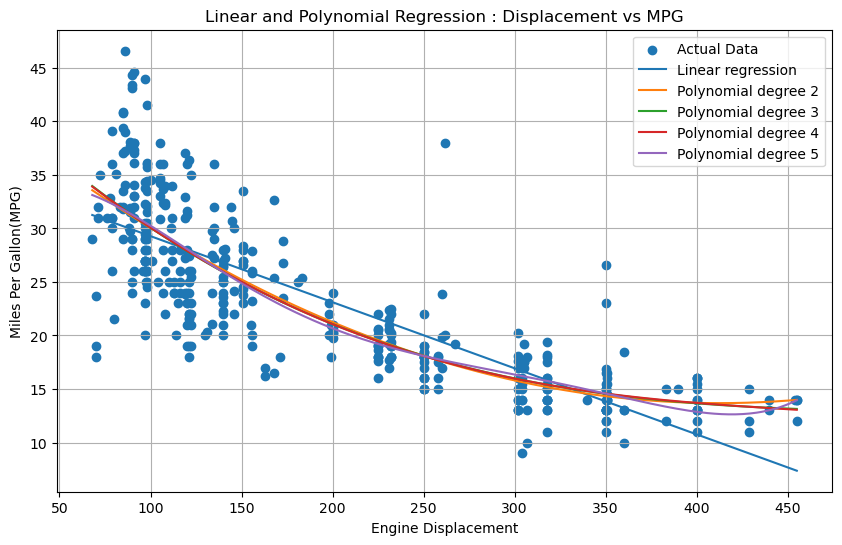

In [50]:
#create smooth x values for plotting
x_plot = pd.DataFrame({
    'displacement':np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300)
})

#create figure
plt.figure(figsize=(10,6))

#plot actual data
plt.scatter(
    x['displacement'],
    y,
    label='Actual Data'
)
#plot linear regression
y_plot_linear = linear_model.predict(x_plot)
plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label='Linear regression'
)
#plot polynomial regression
#degree 2 to 5
for degree in range(2,6):
    #retreive stored transformer and model
    poly = polynomial_models[degree]['poly']
    poly_model = polynomial_models[degree]['model']

    #transform smooth x values
    x_plot_poly = poly.transform(x_plot)

    #predict
    y_plot_poly = poly_model.predict(x_plot_poly)

    #plot curve
    plt.plot(
    x_plot['displacement'],
    y_plot_poly,
    label=f'Polynomial degree {degree}'
    )

    #plot formatting
plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon(MPG)')
plt.title(
    'Linear and Polynomial Regression : Displacement vs MPG'
)
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
bars = plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)

#add labels 
plt.bar_label(bars,fmt='%2f',padding=3)
plt.xlabel("polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("comparison of MSE")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)
plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")
plt.grid(True)
plt.show()

    

NameError: name 'results_df' is not defined

<Figure size 800x500 with 0 Axes>